# Первичный анализ данных — GenAI Cluster Trace

**Цель:** загрузить `pod_gpu_duty_cycle_anon.csv` (целевая переменная — загрузка GPU) и `qps.csv` (нагрузка),  
выровнять временные шкалы, найти пересекающиеся контейнеры, визуализировать ряды и проверить пропуски.

## 1. Загрузка данных

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

In [12]:
gpu_raw = pd.read_csv('../data/raw/pod_gpu_duty_cycle_anon.csv')
qps_raw = pd.read_csv('../data/raw/qps.csv')

print(f'GPU rows: {len(gpu_raw):,}   columns: {list(gpu_raw.columns)}')
print(f'QPS rows: {len(qps_raw):,}   columns: {list(qps_raw.columns)}')

GPU rows: 157,417   columns: ['value', 'timestamp_anon', 'container_ip']
QPS rows: 24,627   columns: ['timestamp_anon', 'value', 'container_ip', 'request_type']


In [13]:
gpu_raw.head(3)

,value,timestamp_anon,container_ip
0,0.0,1.662859e+09,23b8eba99c14e73d454503a55ae96989
1,0.0,1.662859e+09,11415d99a127e215d2148a1f6600007f
2,0.0,1.662859e+09,ae3389e2979abd8ba8c1eeb9868697e0


In [14]:
qps_raw.head(3)

,timestamp_anon,value,container_ip,request_type
0,1.662859e+09,0.09,NaN,API Requests
1,1.662859e+09,0.09,NaN,API Requests
2,1.662859e+09,0.09,dfe00e981377fa8e0a9aefbc9b2e9369,Generative Requests


## 2. Форматы данных и временной шаг

`timestamp_anon` — Unix-время в секундах (float). Конвертируем в `datetime`.

In [15]:
print('=== GPU dtypes ===')
print(gpu_raw.dtypes)
print('\n=== QPS dtypes ===')
print(qps_raw.dtypes)

=== GPU dtypes ===
value             float64
timestamp_anon    float64
container_ip          str
dtype: object

=== QPS dtypes ===
timestamp_anon    float64
value             float64
container_ip          str
request_type          str
dtype: object


In [16]:
# --- Временной шаг между уникальными метками ---
gpu_ts_unique = np.sort(gpu_raw['timestamp_anon'].unique())
qps_ts_unique = np.sort(qps_raw['timestamp_anon'].unique())

gpu_steps = pd.Series(np.diff(gpu_ts_unique))
qps_steps = pd.Series(np.diff(qps_ts_unique))

print('=== GPU: шаг по уникальным timestamp (сек) ===')
print(gpu_steps.value_counts().head(5))
print(f'  медиана = {gpu_steps.median():.1f} с  |  мин = {gpu_steps.min():.1f} с  |  макс = {gpu_steps.max():.1f} с')

print('\n=== QPS: шаг по уникальным timestamp (сек) ===')
print(qps_steps.value_counts().head(5))
print(f'  медиана = {qps_steps.median():.1f} с  |  мин = {qps_steps.min():.1f} с  |  макс = {qps_steps.max():.1f} с')

print(f'\nДиапазон GPU: {gpu_ts_unique[0]:.0f} – {gpu_ts_unique[-1]:.0f}')
print(f'Диапазон QPS: {qps_ts_unique[0]:.0f} – {qps_ts_unique[-1]:.0f}')
span_h = (gpu_ts_unique[-1] - gpu_ts_unique[0]) / 3600
print(f'Охват данных GPU: {span_h:.1f} ч ≈ {span_h/24:.1f} сут')

=== GPU: шаг по уникальным timestamp (сек) ===
57.0    1440
Name: count, dtype: int64
  медиана = 57.0 с  |  мин = 57.0 с  |  макс = 57.0 с

=== QPS: шаг по уникальным timestamp (сек) ===
57.0     1097
114.0      25
171.0       7
228.0       3
570.0       2
Name: count, dtype: int64
  медиана = 57.0 с  |  мин = 57.0 с  |  макс = 3477.0 с

Диапазон GPU: 1662858720 – 1662940800
Диапазон QPS: 1662859176 – 1662939489
Охват данных GPU: 22.8 ч ≈ 1.0 сут


## 3. Проверка пропусков и NULL-значений

In [17]:
def null_report(df, name):
    total = len(df)
    print(f'\n=== {name} ({total:,} строк) ===')
    for col in df.columns:
        n_nan  = df[col].isnull().sum()
        # В ряде файлов NULL приходит строкой
        n_null_str = (df[col].astype(str) == 'NULL').sum() if df[col].dtype == object else 0
        total_miss = n_nan + n_null_str
        pct = total_miss / total * 100
        flag = ' ← ПРОБЛЕМА' if pct > 0 else ''
        print(f'  {col:30s}  NaN={n_nan:>6,}  str(NULL)={n_null_str:>4,}  итого={pct:5.1f}%{flag}')

null_report(gpu_raw, 'pod_gpu_duty_cycle')
null_report(qps_raw, 'qps')


=== pod_gpu_duty_cycle (157,417 строк) ===
  value                           NaN=     0  str(NULL)=   0  итого=  0.0%
  timestamp_anon                  NaN=     0  str(NULL)=   0  итого=  0.0%
  container_ip                    NaN=     0  str(NULL)=   0  итого=  0.0%

=== qps (24,627 строк) ===
  timestamp_anon                  NaN=     0  str(NULL)=   0  итого=  0.0%
  value                           NaN=     0  str(NULL)=   0  итого=  0.0%
  container_ip                    NaN= 1,114  str(NULL)=   0  итого=  4.5% ← ПРОБЛЕМА
  request_type                    NaN=     0  str(NULL)=   0  итого=  0.0%


### Стратегия обработки пропусков

| Столбец | Проблема | Стратегия |
|---------|----------|-----------|
| `qps.container_ip` | ~4.5 % NaN (API Requests без привязки к контейнеру) | Оставить для агрегации по времени; при join по `container_ip` — **удалить** строки с NaN |
| Строка `"NULL"` (в latency-файлах) | Текстовый маркер | При загрузке передать `na_values=['NULL']` |
| Временные пропуски в ряду | Несинхронные шаги | После агрегации по 5-мин окнам применить **ffill** (заполнение предыдущим значением) |

## 4. Поиск наилучшего общего container_ip

Выберем контейнер с максимальным суммарным числом записей в обоих файлах.

In [18]:
gpu_cnt = gpu_raw['container_ip'].value_counts().rename('gpu_count')
qps_valid = qps_raw.dropna(subset=['container_ip'])
qps_cnt  = qps_valid['container_ip'].value_counts().rename('qps_count')

overlap = pd.concat([gpu_cnt, qps_cnt], axis=1).dropna()
overlap['total'] = overlap['gpu_count'] + overlap['qps_count']
overlap = overlap.sort_values('total', ascending=False)

print(f'Уникальных IP в GPU:  {len(gpu_cnt)}')
print(f'Уникальных IP в QPS (non-null): {len(qps_cnt)}')
print(f'Общих IP: {len(overlap)}')
print('\nТоп-5 контейнеров по суммарным записям:')
display(overlap.head(5))

BEST_IP = overlap.index[0]
print(f'\n→ Выбран контейнер: {BEST_IP}')

Уникальных IP в GPU:  143
Уникальных IP в QPS (non-null): 107
Общих IP: 107

Топ-5 контейнеров по суммарным записям:


,gpu_count,qps_count,total
container_ip,,,
2a879423614836f63138bd4162830d8b,1441,301.0,1742.0
aa387669ec783d3503866571da0357f2,1441,300.0,1741.0
fd2e6a49d33e73344135073433648309,1441,294.0,1735.0
81202f3feffc31e32dbfcb7c74b72b61,1441,294.0,1735.0
e912439b988c0f3e26118d84d923f677,1441,293.0,1734.0



→ Выбран контейнер: 2a879423614836f63138bd4162830d8b


## 5. Подготовка и агрегация по 5-минутным окнам

По рекомендации документации: **суммируем QPS** по всем контейнерам в каждом временном окне (агрегация по времени),  
а GPU-нагрузку берём по выбранному `BEST_IP`.

In [19]:
WINDOW = '5min'

# --- GPU: один контейнер ---
gpu_node = gpu_raw[gpu_raw['container_ip'] == BEST_IP].copy()
gpu_node['dt'] = pd.to_datetime(gpu_node['timestamp_anon'], unit='s')
gpu_node = gpu_node.set_index('dt').sort_index()
gpu_agg = gpu_node['value'].resample(WINDOW).mean().rename('gpu_util')

# --- QPS: агрегируем ВСЕ записи (включая NaN container_ip) по времени ---
#     Фильтруем только Generative Requests для более прямой связи с GPU
qps_gen = qps_raw[qps_raw['request_type'] == 'Generative Requests'].copy()
qps_gen['dt'] = pd.to_datetime(qps_gen['timestamp_anon'], unit='s')
qps_gen = qps_gen.set_index('dt').sort_index()
qps_agg_gen = qps_gen['value'].resample(WINDOW).sum().rename('qps_generative')

# Также суммируем QPS для ВЫБРАННОГО контейнера (чтобы сравнить подходы)
qps_node = qps_valid[qps_valid['container_ip'] == BEST_IP].copy()
qps_node['dt'] = pd.to_datetime(qps_node['timestamp_anon'], unit='s')
qps_node = qps_node.set_index('dt').sort_index()
qps_agg_node = qps_node['value'].resample(WINDOW).sum().rename('qps_node')

# --- Объединяем по индексу (dt) ---
merged = pd.concat([gpu_agg, qps_agg_gen, qps_agg_node], axis=1)
merged = merged.ffill()   # заполнение пропусков методом ffill
merged = merged.dropna()  # удаляем строки вне пересечения временных диапазонов

print(f'Записей после агрегации ({WINDOW}) и выравнивания: {len(merged)}')
print(f'Временной диапазон: {merged.index[0]}  →  {merged.index[-1]}')
display(merged.head(5))

Записей после агрегации (5min) и выравнивания: 268
Временной диапазон: 2022-09-11 01:45:00  →  2022-09-12 00:00:00


,gpu_util,qps_generative,qps_node
dt,,,
2022-09-11 01:45:00,7.626667,0.63,0.09
2022-09-11 01:50:00,1.800000,0.45,0.00
2022-09-11 01:55:00,12.106667,2.97,0.18
2022-09-11 02:00:00,3.306667,2.61,0.00
2022-09-11 02:05:00,4.277778,6.12,0.09


## 6. Визуализация: двойной временной ряд (GPU vs QPS)

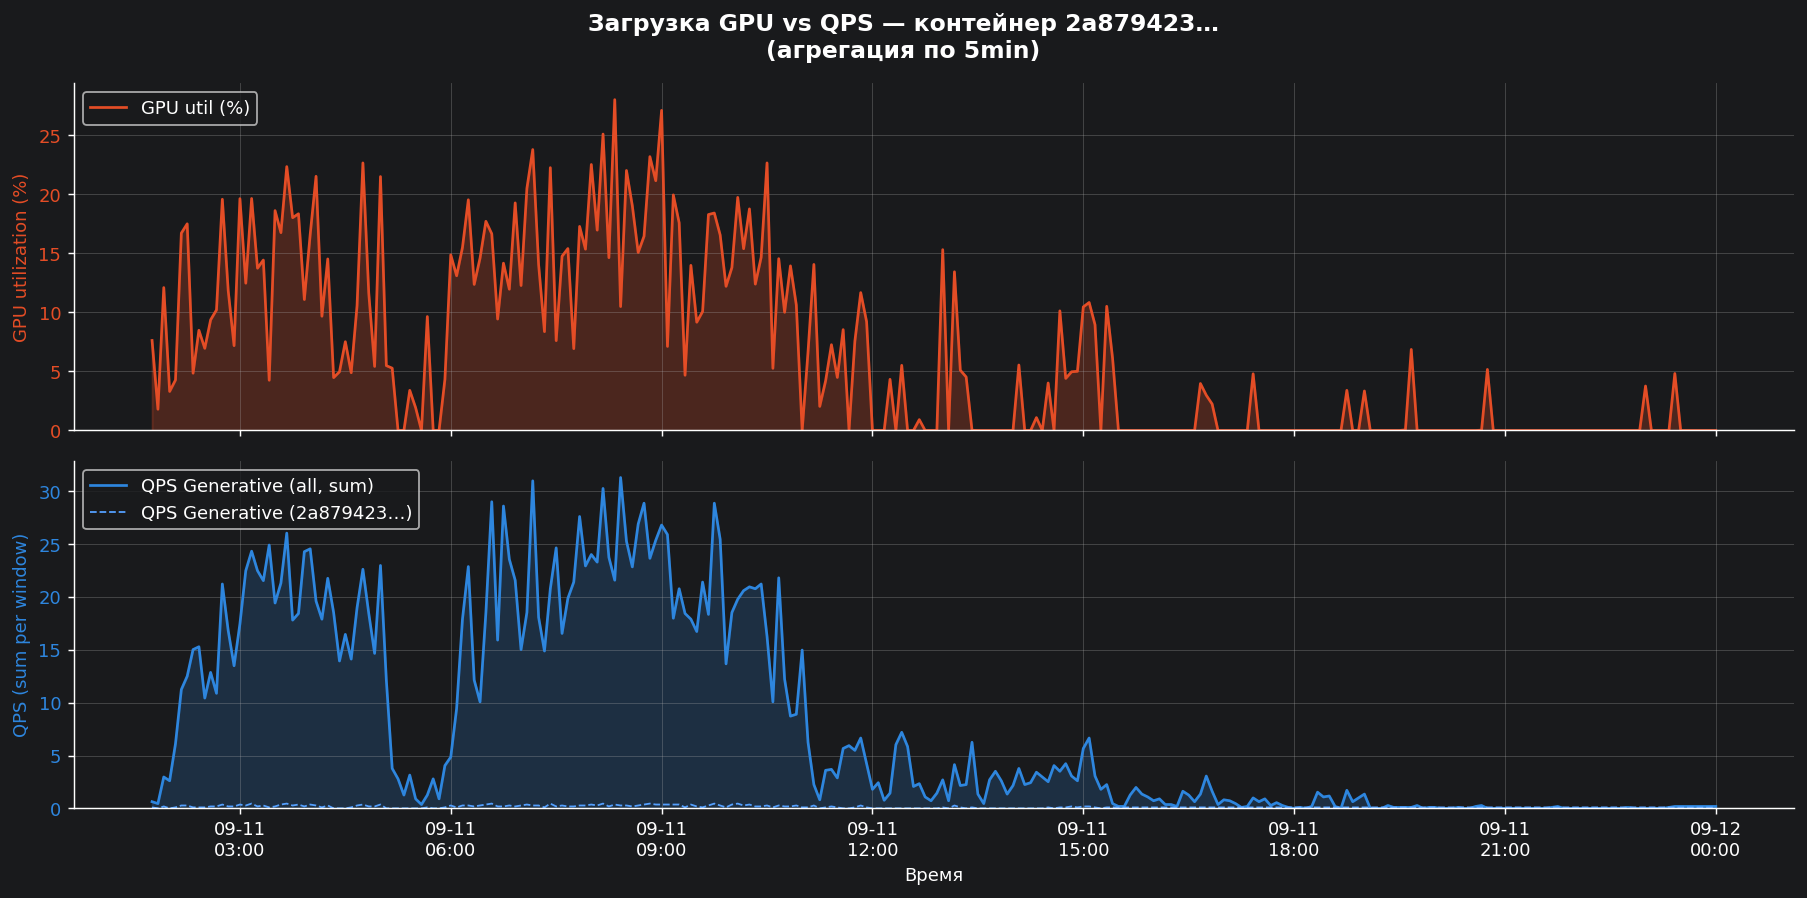

График сохранён: data/processed/gpu_vs_qps_timeseries.png


In [20]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle(
    f'Загрузка GPU vs QPS — контейнер {BEST_IP[:8]}…\n'
    f'(агрегация по {WINDOW})',
    fontsize=13, fontweight='bold'
)

# --- GPU utilization ---
ax1.fill_between(merged.index, merged['gpu_util'], alpha=0.25, color='#e44d26')
ax1.plot(merged.index, merged['gpu_util'], color='#e44d26', linewidth=1.5, label='GPU util (%)')
ax1.set_ylabel('GPU utilization (%)', color='#e44d26')
ax1.tick_params(axis='y', labelcolor='#e44d26')
ax1.set_ylim(bottom=0)
ax1.legend(loc='upper left')

# --- QPS (Generative Requests, all containers) ---
ax2.fill_between(merged.index, merged['qps_generative'], alpha=0.2, color='#2e86de')
ax2.plot(merged.index, merged['qps_generative'], color='#2e86de', linewidth=1.5, label='QPS Generative (all, sum)')
ax2.plot(merged.index, merged['qps_node'], color='#54a0ff', linewidth=1.0,
         linestyle='--', label=f'QPS Generative ({BEST_IP[:8]}…)')
ax2.set_ylabel('QPS (sum per window)', color='#2e86de')
ax2.tick_params(axis='y', labelcolor='#2e86de')
ax2.set_ylim(bottom=0)
ax2.legend(loc='upper left')
ax2.set_xlabel('Время')

# Форматируем ось X
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
fig.autofmt_xdate(rotation=0, ha='center')

plt.tight_layout()
plt.savefig('../data/processed/gpu_vs_qps_timeseries.png', bbox_inches='tight')
plt.show()
print('График сохранён: data/processed/gpu_vs_qps_timeseries.png')

## 7. Корреляция и скользящее сглаживание

Корреляция GPU ~ QPS_Generative (all):  r = 0.850
Корреляция GPU ~ QPS_node (2a879423…): r = 0.848


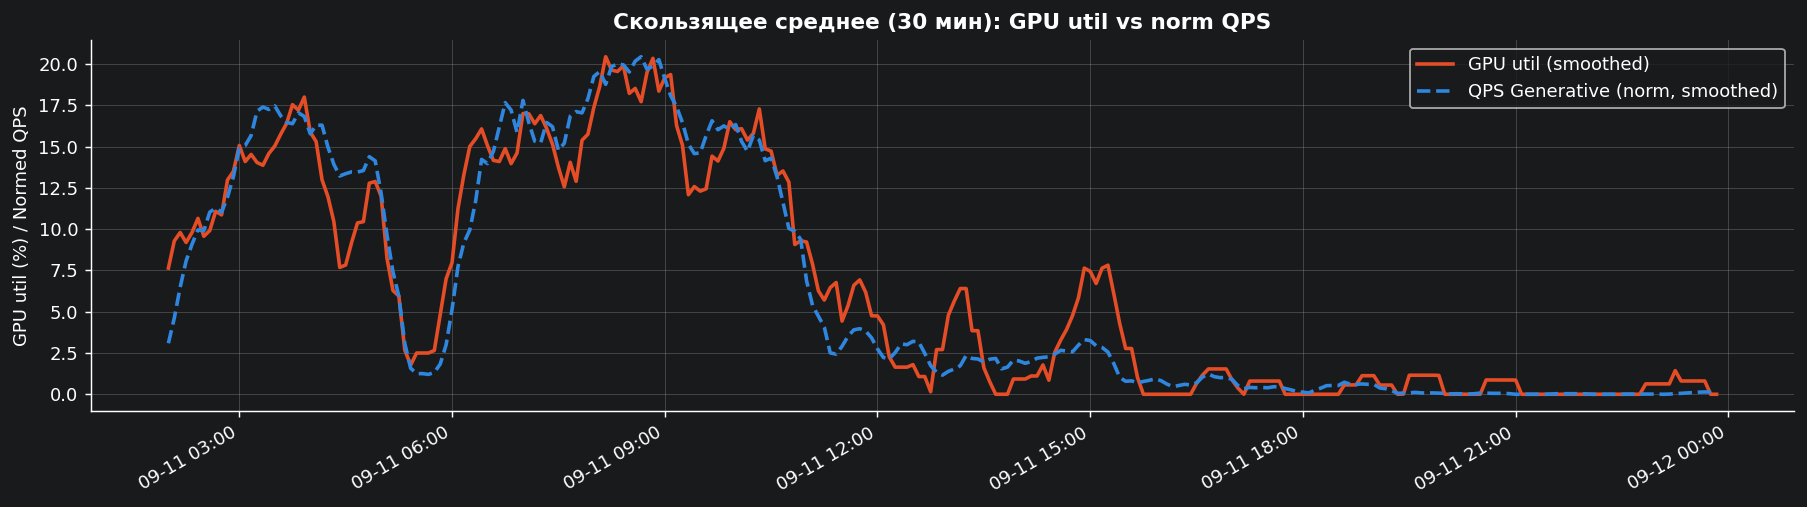

In [21]:
# Pearson correlation
corr_gen  = merged['gpu_util'].corr(merged['qps_generative'])
corr_node = merged['gpu_util'].corr(merged['qps_node'])
print(f'Корреляция GPU ~ QPS_Generative (all):  r = {corr_gen:.3f}')
print(f'Корреляция GPU ~ QPS_node ({BEST_IP[:8]}…): r = {corr_node:.3f}')

# Сглаженный вид
ROLL = 6  # 6 × 5 мин = 30 мин скользящее среднее
fig, ax = plt.subplots(figsize=(14, 4))
ax.set_title('Скользящее среднее (30 мин): GPU util vs norm QPS', fontsize=12, fontweight='bold')

gpu_smooth = merged['gpu_util'].rolling(ROLL, center=True).mean()
qps_smooth = merged['qps_generative'].rolling(ROLL, center=True).mean()
# Нормализуем QPS для наложения
qps_norm = (qps_smooth - qps_smooth.min()) / (qps_smooth.max() - qps_smooth.min()) * gpu_smooth.max()

ax.plot(merged.index, gpu_smooth, color='#e44d26', linewidth=2, label='GPU util (smoothed)')
ax.plot(merged.index, qps_norm, color='#2e86de', linewidth=2, linestyle='--', label='QPS Generative (norm, smoothed)')
ax.set_ylabel('GPU util (%) / Normed QPS')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('../data/processed/gpu_vs_qps_smoothed.png', bbox_inches='tight')
plt.show()

## 8. Итоговый отчёт по результатам EDA

In [22]:
print('=' * 60)
print('ИТОГИ ПЕРВИЧНОГО АНАЛИЗА')
print('=' * 60)

print(f"""
Файлы:
  pod_gpu_duty_cycle_anon.csv : {len(gpu_raw):>7,} строк, 3 колонки
  qps.csv                     : {len(qps_raw):>7,} строк, 4 колонки

Форматы:
  timestamp_anon — float64 (Unix-секунды), нужна конвертация в datetime
  value          — float64
  container_ip   — object (MD5-хэш)
  request_type   — object (только в QPS)

Временной шаг:
  GPU: между уникальными timestamp — 57 сек (~1 мин)
  QPS: аналогично ~57 сек, но записи внутри одного timestamp
       относятся к разным контейнерам
  → Рекомендуемое окно агрегации: 5–10 минут

Пропуски:
  GPU  : 0 пропусков в любом столбце ✓
  QPS  : container_ip — {qps_raw['container_ip'].isnull().sum()} NaN из {len(qps_raw):,} ({qps_raw['container_ip'].isnull().mean()*100:.1f}%)
         (это записи типа 'API Requests' без привязки к контейнеру)
  Строковые 'NULL': отсутствуют в gpu и qps (характерны для latency-файлов)

Перекрытие по container_ip:
  GPU: {len(gpu_cnt)} уникальных IP
  QPS: {len(qps_cnt)} уникальных IP (non-null)
  Общих: {len(overlap)} — ВСЕ QPS-контейнеры есть в GPU! ✓

Выбранный контейнер для анализа: {BEST_IP}
  GPU записей: {overlap.loc[BEST_IP, 'gpu_count']:.0f}
  QPS записей: {overlap.loc[BEST_IP, 'qps_count']:.0f}

Корреляция (после агрегации {WINDOW}):
  GPU ~ QPS_Generative (все контейнеры): r = {corr_gen:.3f}
  GPU ~ QPS_node (один контейнер)      : r = {corr_node:.3f}

Трудности при объединении:
  1. АСИММЕТРИЯ РАЗМЕРОВ: GPU имеет 143 контейнера × 1441 шаг = 157K строк;
     QPS имеет ~107 контейнеров × ~230 точек = 24K строк — в 6× меньше.
  2. NaN в container_ip QPS: 1114 строк (4.5%) не связаны с конкретным
     контейнером — эти строки теряются при inner join.
  3. ВРЕМЕННАЯ НЕСИНХРОННОСТЬ: raw QPS охватывает более короткий
     диапазон, чем GPU (сдвиг ~14 мин в начале). Без resample().
     merge по timestamp дал бы много NaN.
  → Решение: агрегация обоих рядов по единой сетке resample({WINDOW})
     с последующим ffill() и inner join по datetime-индексу.
""")

ИТОГИ ПЕРВИЧНОГО АНАЛИЗА

Файлы:
  pod_gpu_duty_cycle_anon.csv : 157,417 строк, 3 колонки
  qps.csv                     :  24,627 строк, 4 колонки

Форматы:
  timestamp_anon — float64 (Unix-секунды), нужна конвертация в datetime
  value          — float64
  container_ip   — object (MD5-хэш)
  request_type   — object (только в QPS)

Временной шаг:
  GPU: между уникальными timestamp — 57 сек (~1 мин)
  QPS: аналогично ~57 сек, но записи внутри одного timestamp
       относятся к разным контейнерам
  → Рекомендуемое окно агрегации: 5–10 минут

Пропуски:
  GPU  : 0 пропусков в любом столбце ✓
  QPS  : container_ip — 1114 NaN из 24,627 (4.5%)
         (это записи типа 'API Requests' без привязки к контейнеру)
  Строковые 'NULL': отсутствуют в gpu и qps (характерны для latency-файлов)

Перекрытие по container_ip:
  GPU: 143 уникальных IP
  QPS: 107 уникальных IP (non-null)
  Общих: 107 — ВСЕ QPS-контейнеры есть в GPU! ✓

Выбранный контейнер для анализа: 2a879423614836f63138bd4162830d8b
  GPU